In [1]:
# Import libraries
import math
import copy
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from tqdm import tqdm
import matplotlib.pyplot as plt
import imageio.v2 as imageio
from io import BytesIO
from IPython.display import Image, display

In [2]:
# Training configuration and hyperparameters
device = "cuda" if torch.cuda.is_available() else "cpu"
print(torch.cuda.get_device_name(0))

batch_size = 128
epochs = 20
lr = 2e-4
timesteps = 200
img_size = 32

Tesla T4


In [3]:
# Load and prepare the MNIST dataset
transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    drop_last=True,
)

In [4]:
# Sinusoidal timestep embedding - model needs to know which diffusion step (t) are currently denoising.
class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half_dim = self.dim // 2
        emb_scale = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=t.device) * -emb_scale)
        emb = t[:, None].float() * emb[None, :]
        emb = torch.cat([emb.sin(), emb.cos()], dim=1)
        return emb

In [5]:
# Residual block used in the U-Net
class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim, groups=8):
        super().__init__()
        self.norm1 = nn.GroupNorm(groups, in_ch)
        self.act1 = nn.SiLU()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)

        self.norm2 = nn.GroupNorm(groups, out_ch)
        self.act2 = nn.SiLU()
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)

        self.time_mlp = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_dim, out_ch)
        )

        self.res_conv = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = self.conv1(self.act1(self.norm1(x)))
        h = h + self.time_mlp(t_emb)[:, :, None, None]
        h = self.conv2(self.act2(self.norm2(h)))
        return h + self.res_conv(x)

In [6]:
# Downsampling and upsampling layers
class Downsample(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv = nn.Conv2d(ch, ch, 4, stride=2, padding=1)

    def forward(self, x):
        return self.conv(x)

class Upsample(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv = nn.ConvTranspose2d(ch, ch, 4, stride=2, padding=1)

    def forward(self, x):
        return self.conv(x)

In [7]:
# U-Net architecture for noise prediction
class SmallUNet(nn.Module):
    def __init__(self, in_ch=1, base_ch=32, time_dim=128):
        super().__init__()

        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim),
        )

        self.init_conv = nn.Conv2d(in_ch, base_ch, 3, padding=1)

        # Down
        self.down1_block1 = ResidualBlock(base_ch, base_ch, time_dim)
        self.down1_block2 = ResidualBlock(base_ch, base_ch, time_dim)
        self.down1 = Downsample(base_ch)

        self.down2_block1 = ResidualBlock(base_ch, base_ch * 2, time_dim)
        self.down2_block2 = ResidualBlock(base_ch * 2, base_ch * 2, time_dim)
        self.down2 = Downsample(base_ch * 2)

        # Bottleneck
        self.mid1 = ResidualBlock(base_ch * 2, base_ch * 4, time_dim)
        self.mid2 = ResidualBlock(base_ch * 4, base_ch * 4, time_dim)

        # Up
        self.up2 = Upsample(base_ch * 4)
        self.up2_block1 = ResidualBlock(base_ch * 4 + base_ch * 2, base_ch * 2, time_dim)
        self.up2_block2 = ResidualBlock(base_ch * 2, base_ch * 2, time_dim)

        self.up1 = Upsample(base_ch * 2)
        self.up1_block1 = ResidualBlock(base_ch * 2 + base_ch, base_ch, time_dim)
        self.up1_block2 = ResidualBlock(base_ch, base_ch, time_dim)

        self.final = nn.Sequential(
            nn.GroupNorm(8, base_ch),
            nn.SiLU(),
            nn.Conv2d(base_ch, in_ch, 1)
        )

    def forward(self, x, t):
        t_emb = self.time_mlp(t)

        x = self.init_conv(x)

        s1 = self.down1_block1(x, t_emb)
        s1 = self.down1_block2(s1, t_emb)
        x = self.down1(s1)

        s2 = self.down2_block1(x, t_emb)
        s2 = self.down2_block2(s2, t_emb)
        x = self.down2(s2)

        x = self.mid1(x, t_emb)
        x = self.mid2(x, t_emb)

        x = self.up2(x)
        x = torch.cat([x, s2], dim=1)
        x = self.up2_block1(x, t_emb)
        x = self.up2_block2(x, t_emb)

        x = self.up1(x)
        x = torch.cat([x, s1], dim=1)
        x = self.up1_block1(x, t_emb)
        x = self.up1_block2(x, t_emb)

        return self.final(x)

In [8]:
# Exponential Moving Average (EMA)
class EMA:
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.ema_model = copy.deepcopy(model).eval().requires_grad_(False)

    @torch.no_grad()
    def update(self, model):
        msd = model.state_dict()
        for k, v in self.ema_model.state_dict().items():
            if v.dtype.is_floating_point:
                v.mul_(self.decay).add_(msd[k], alpha=1 - self.decay)
            else:
                v.copy_(msd[k])

In [9]:
model = SmallUNet(in_ch=1, base_ch=32, time_dim=128).to(device)
ema = EMA(model, decay=0.999)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

In [10]:
# Diffusion noise schedule
beta_start = 1e-4
beta_end = 0.02

betas = torch.linspace(beta_start, beta_end, timesteps, device=device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
alphas_cumprod_prev = torch.cat([torch.tensor([1.0], device=device), alphas_cumprod[:-1]], dim=0)

sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)
sqrt_recip_alphas = torch.sqrt(1.0 / alphas)

posterior_variance = betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)

In [11]:
# Training loop
for epoch in range(epochs):
    model.train()
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
    running_loss = 0.0

    for imgs, _ in pbar:
        imgs = imgs.to(device, non_blocking=True)

        t = torch.randint(0, timesteps, (imgs.size(0),), device=device)
        noise = torch.randn_like(imgs)

        x_t = (
            sqrt_alphas_cumprod[t, None, None, None] * imgs +
            sqrt_one_minus_alphas_cumprod[t, None, None, None] * noise
        )

        pred_noise = model(x_t, t)
        loss = F.mse_loss(pred_noise, noise)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        ema.update(model)

        running_loss += loss.item()
        pbar.set_postfix(loss=loss.item())

    print(f"Epoch {epoch+1}: avg loss = {running_loss / len(train_loader):.4f}")

Epoch 1/20: 100%|██████████| 468/468 [01:01<00:00,  7.61it/s, loss=0.0565]


Epoch 1: avg loss = 0.0927


Epoch 2/20: 100%|██████████| 468/468 [00:58<00:00,  7.93it/s, loss=0.0427]


Epoch 2: avg loss = 0.0493


Epoch 3/20: 100%|██████████| 468/468 [00:58<00:00,  8.06it/s, loss=0.0456]


...

Epoch 18: avg loss = 0.0319


Epoch 19/20: 100%|██████████| 468/468 [00:58<00:00,  8.01it/s, loss=0.0313]


Epoch 19: avg loss = 0.0320


Epoch 20/20: 100%|██████████| 468/468 [00:58<00:00,  7.99it/s, loss=0.0312]

Epoch 20: avg loss = 0.0316


In [12]:
# DDPM sampling
@torch.no_grad()
def sample_ddpm(model, n_samples=16):
    model.eval()
    x = torch.randn(n_samples, 1, img_size, img_size, device=device)

    for t in reversed(range(timesteps)):
        t_batch = torch.full((n_samples,), t, device=device, dtype=torch.long)
        pred_noise = model(x, t_batch)

        beta_t = betas[t]
        sqrt_one_minus_alpha_bar_t = sqrt_one_minus_alphas_cumprod[t]
        sqrt_recip_alpha_t = sqrt_recip_alphas[t]

        model_mean = sqrt_recip_alpha_t * (
            x - beta_t * pred_noise / sqrt_one_minus_alpha_bar_t
        )

        if t > 0:
            noise = torch.randn_like(x)
            x = model_mean + torch.sqrt(posterior_variance[t]) * noise
        else:
            x = model_mean

    return x

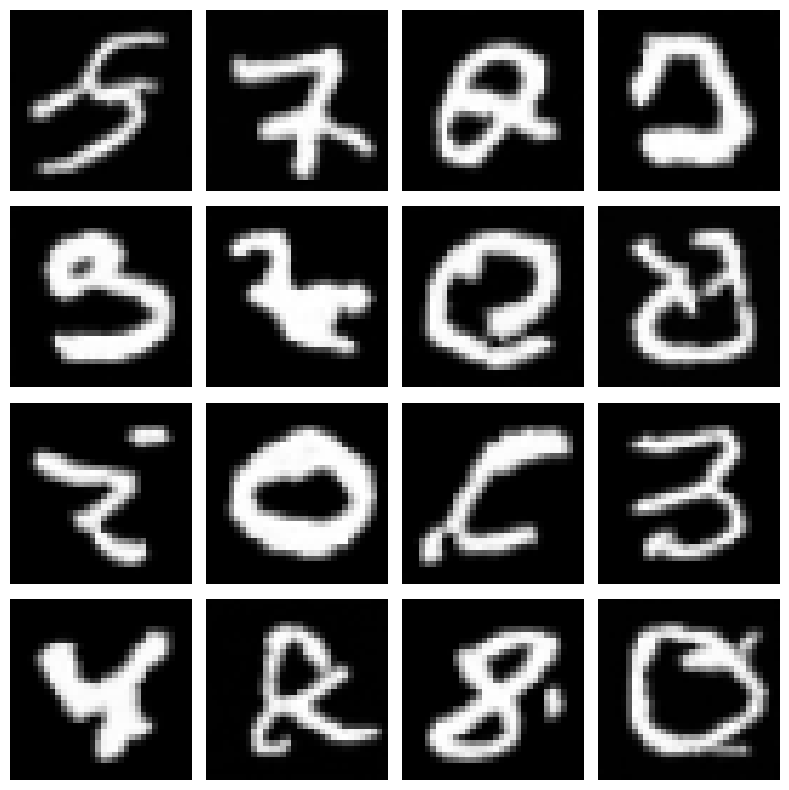

In [17]:
# Visualize generated samples
@torch.no_grad()
def show_samples(model, n_samples=16):
    samples = sample_ddpm(model, n_samples=n_samples).cpu()
    samples = ((samples.clamp(-1, 1) + 1) / 2)

    rows = int(math.sqrt(n_samples))
    cols = math.ceil(n_samples / rows)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
    axes = axes.flatten()

    for i in range(n_samples):
        axes[i].imshow(samples[i, 0], cmap="gray")
        axes[i].axis("off")

    for i in range(n_samples, len(axes)):
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

show_samples(ema.ema_model, n_samples=16)

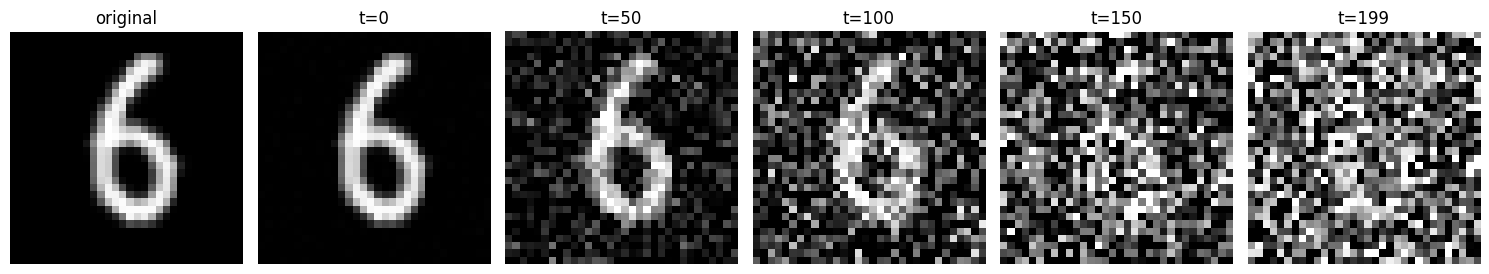

In [14]:
# Visualizing the forward diffusion process
imgs, _ = next(iter(train_loader)) # Get one batch
x0 = imgs[0:1].to(device)   # one image, shape [1, 1, H, W]

# Timesteps to visualize
show_ts = [0, timesteps // 4, timesteps // 2, 3 * timesteps // 4, timesteps - 1]
fig, axes = plt.subplots(1, len(show_ts) + 1, figsize=(15, 3))

# Original image
orig = ((x0[0].detach().cpu().clamp(-1, 1) + 1) / 2)
axes[0].imshow(orig[0], cmap="gray")
axes[0].set_title("original")
axes[0].axis("off")

# Noisy versions
for i, t in enumerate(show_ts):
    t_tensor = torch.tensor([t], device=device)
    noise = torch.randn_like(x0)

    x_t = (
        sqrt_alphas_cumprod[t_tensor, None, None, None] * x0
        + sqrt_one_minus_alphas_cumprod[t_tensor, None, None, None] * noise
    )

    img = ((x_t[0].detach().cpu().clamp(-1, 1) + 1) / 2)
    axes[i + 1].imshow(img[0], cmap="gray")
    axes[i + 1].set_title(f"t={t}")
    axes[i + 1].axis("off")

plt.tight_layout()
plt.show()

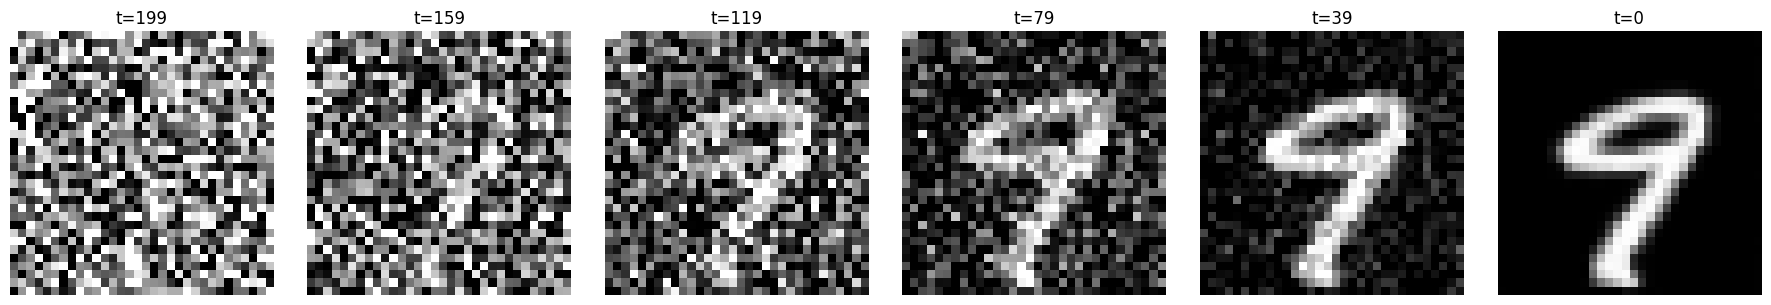

In [21]:
# Visualizing the reverse diffusion process
@torch.no_grad()
def visualize_denoising(model, img_size=32, ncols=6):
    model.eval()

    x = torch.randn(1, 1, img_size, img_size, device=device)

    # Timesteps to display during reverse process
    show_ts = torch.linspace(timesteps - 1, 0, steps=ncols, dtype=torch.long).tolist()
    show_ts = [int(t) for t in show_ts]

    saved = {}
    saved[timesteps - 1] = x.detach().cpu()

    for t in reversed(range(timesteps)):
        t_batch = torch.full((1,), t, device=device, dtype=torch.long)

        pred_noise = model(x, t_batch)

        beta_t = betas[t]
        alpha_t = alphas[t]
        alpha_bar_t = alphas_cumprod[t]
        sqrt_one_minus_alpha_bar_t = torch.sqrt(1 - alpha_bar_t)
        sqrt_recip_alpha_t = sqrt_recip_alphas[t]

        model_mean = sqrt_recip_alpha_t * (
            x - beta_t * pred_noise / sqrt_one_minus_alpha_bar_t
        )

        if t > 0:
            noise = torch.randn_like(x)
            x = model_mean + torch.sqrt(posterior_variance[t]) * noise
        else:
            x = model_mean

        if t in show_ts:
            saved[t] = x.detach().cpu()

    fig, axes = plt.subplots(1, len(show_ts), figsize=(3 * len(show_ts), 3))

    for i, t in enumerate(show_ts):
        img = saved[t][0]
        img = ((img.clamp(-1, 1) + 1) / 2)
        axes[i].imshow(img[0], cmap="gray")
        axes[i].set_title(f"t={t}")
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

visualize_denoising(ema.ema_model if "ema" in globals() else model, img_size=img_size, ncols=6)

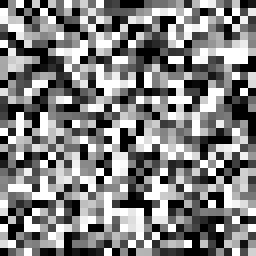

In [22]:
# Animated visualization of the denoising process
@torch.no_grad()
def show_denoising_gif(
    model,
    img_size=32,
    max_frames=80,
    scale=8,
    frame_duration=0.08,
):
    model.eval()

    # Start from pure noise
    x = torch.randn(1, 1, img_size, img_size, device=device)

    # Choose timesteps to capture
    frame_ts = np.linspace(timesteps - 1, 0, max_frames, dtype=int)
    frame_ts = sorted(set(frame_ts.tolist()), reverse=True)

    frames = []

    for t in reversed(range(timesteps)):
        t_batch = torch.full((1,), t, device=device, dtype=torch.long)

        pred_noise = model(x, t_batch)

        beta_t = betas[t]
        sqrt_one_minus_alpha_bar_t = sqrt_one_minus_alphas_cumprod[t]
        sqrt_recip_alpha_t = sqrt_recip_alphas[t]

        model_mean = sqrt_recip_alpha_t * (
            x - beta_t * pred_noise / sqrt_one_minus_alpha_bar_t
        )

        if t > 0:
            noise = torch.randn_like(x)
            x = model_mean + torch.sqrt(posterior_variance[t]) * noise
        else:
            x = model_mean

        if t in frame_ts:
            img = x[0, 0].detach().cpu().clamp(-1, 1)
            img = ((img + 1) / 2).numpy()              # [-1,1] -> [0,1]
            img = (img * 255).astype(np.uint8)        # -> uint8

            # Upscale for better notebook display
            img = np.kron(img, np.ones((scale, scale))).astype(np.uint8)

            frames.append(img)

    img = x[0, 0].detach().cpu().clamp(-1, 1)
    img = ((img + 1) / 2).numpy()
    img = (img * 255).astype(np.uint8)
    img = np.kron(img, np.ones((scale, scale))).astype(np.uint8)
    frames.append(img)

    # Save GIF in memory
    gif_buffer = BytesIO()
    imageio.mimsave(gif_buffer, frames, format="GIF", duration=frame_duration, loop=0)
    gif_buffer.seek(0)

    display(Image(data=gif_buffer.read()))

show_denoising_gif(
    ema.ema_model if "ema" in globals() else model,
    img_size=img_size,
    max_frames=80,
    scale=8,
    frame_duration=0.08,
)